# Random-forest surrogate leaf policies

Ranking and best-so-far trajectories for the 27 adaptive and 3 fixed `min_samples_leaf` policies.

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

HERE = Path.cwd()
if HERE.name != "02_easy_policy":
    HERE = Path("experiments/HPOBench/random_forest/02_easy_policy").resolve()

paths = sorted((HERE / "adaptive_output").glob("adaptive_*/*/trajectory.json"))
paths += sorted((HERE / "fixed_output").glob("fixed_*/*/trajectory.json"))
if not paths:
    raise FileNotFoundError(
        "No trajectories found. Run the adaptive and fixed Submitit scripts first."
    )

results = [json.loads(path.read_text()) for path in paths]
print(f"Loaded {len(results)}/30 policy trajectories.")

Loaded 30/30 policy trajectories.


In [7]:
ranking = pd.DataFrame([
    {
        "policy": result["policy_name"],
        "type": result["policy_type"],
        "final_best": result["best_so_far"][-1],
        "evaluated_trials": len(result["best_so_far"]),
    }
    for result in results
]).sort_values(["final_best", "policy"], ignore_index=True)
ranking.index = ranking.index + 1
ranking.index.name = "rank"
ranking

,policy,type,final_best,evaluated_trials
rank,,,,
1,adaptive_1_1_1,adaptive,0.103139,300
2,adaptive_1_1_2,adaptive,0.103139,300
3,adaptive_1_1_3,adaptive,0.103139,300
4,adaptive_1_3_1,adaptive,0.103139,300
5,adaptive_1_3_2,adaptive,0.103139,300
6,adaptive_1_3_3,adaptive,0.103139,300
7,adaptive_2_2_1,adaptive,0.103139,300
8,adaptive_2_2_2,adaptive,0.103139,300
9,adaptive_2_2_3,adaptive,0.103139,300


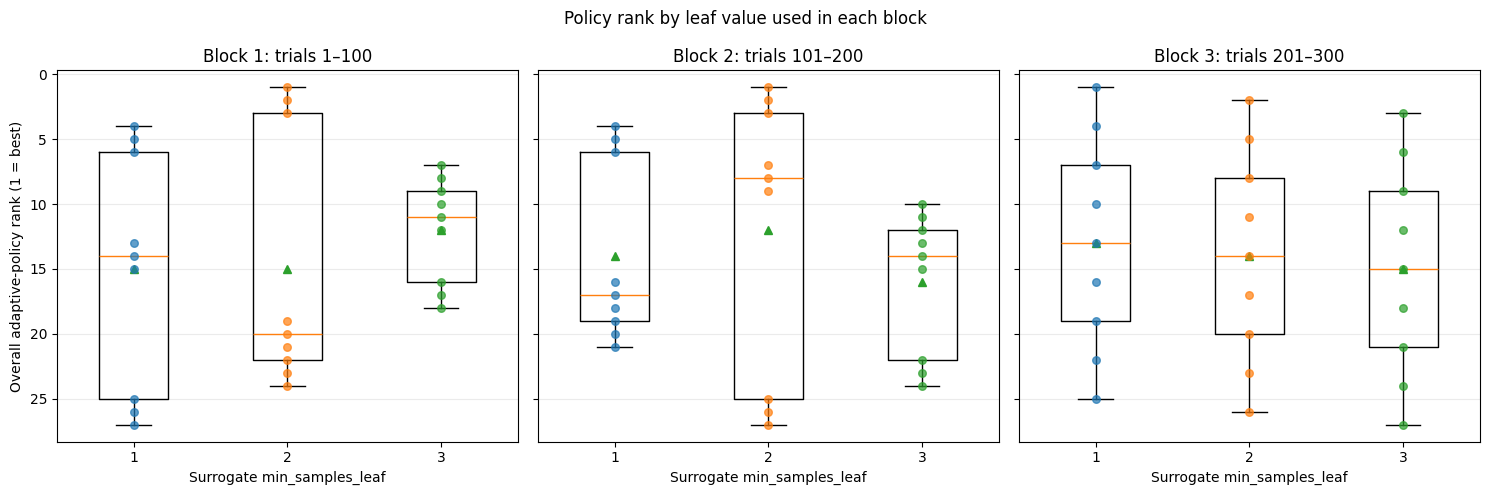

,policy,final_best,mean_best_so_far
policy_rank,,,
1,adaptive_2_2_1,0.103139,0.116921
2,adaptive_2_2_2,0.103139,0.116921
3,adaptive_2_2_3,0.103139,0.116921
4,adaptive_1_1_1,0.103139,0.123124
5,adaptive_1_1_2,0.103139,0.123124
6,adaptive_1_1_3,0.103139,0.123124
7,adaptive_3_2_1,0.103139,0.123946
8,adaptive_3_2_2,0.103139,0.123946
9,adaptive_3_2_3,0.103139,0.123946


,policy,block,end_trial,min_samples_leaf,best_at_block_end,policy_rank
36,adaptive_2_2_1,1,100,2,0.116592,1
39,adaptive_2_2_2,1,100,2,0.116592,2
42,adaptive_2_2_3,1,100,2,0.116592,3
0,adaptive_1_1_1,1,100,1,0.125561,4
3,adaptive_1_1_2,1,100,1,0.125561,5
6,adaptive_1_1_3,1,100,1,0.125561,6
63,adaptive_3_2_1,1,100,3,0.125561,7
66,adaptive_3_2_2,1,100,3,0.125561,8
69,adaptive_3_2_3,1,100,3,0.125561,9
72,adaptive_3_3_1,1,100,3,0.125561,10


In [8]:
# Assign each adaptive policy one performance rank from 1 to 27.
# Final loss is primary; mean best-so-far loss breaks the many final-loss ties.
adaptive_results = [result for result in results if result["policy_type"] == "adaptive"]
adaptive_ranking = pd.DataFrame([
    {
        "policy": result["policy_name"],
        "final_best": result["best_so_far"][-1],
        "mean_best_so_far": sum(result["best_so_far"]) / len(result["best_so_far"]),
    }
    for result in adaptive_results
]).sort_values(["final_best", "mean_best_so_far", "policy"], ignore_index=True)
adaptive_ranking["policy_rank"] = range(1, len(adaptive_ranking) + 1)
policy_rank = adaptive_ranking.set_index("policy")["policy_rank"]

block_rows = []
for result in adaptive_results:
    policy = result["min_samples_leaf_by_block"]
    for block, end_trial in enumerate((100, 200, 300), start=1):
        block_rows.append({
            "policy": result["policy_name"],
            "block": block,
            "end_trial": end_trial,
            "min_samples_leaf": policy[block - 1],
            "best_at_block_end": result["best_so_far"][end_trial - 1],
            "policy_rank": policy_rank[result["policy_name"]],
        })

block_ranks = pd.DataFrame(block_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for block, ax in enumerate(axes, start=1):
    data = block_ranks[block_ranks["block"] == block]
    groups = [data.loc[data["min_samples_leaf"] == leaf, "policy_rank"] for leaf in (1, 2, 3)]
    ax.boxplot(groups, positions=(1, 2, 3), widths=0.45, showmeans=True)
    for leaf in (1, 2, 3):
        ranks = data.loc[data["min_samples_leaf"] == leaf, "policy_rank"]
        ax.scatter([leaf] * len(ranks), ranks, alpha=0.7, s=30, zorder=3)
    ax.set(
        title=f"Block {block}: trials {(block - 1) * 100 + 1}–{block * 100}",
        xlabel="Surrogate min_samples_leaf",
        xticks=(1, 2, 3),
    )
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Overall adaptive-policy rank (1 = best)")
axes[0].invert_yaxis()
fig.suptitle("Policy rank by leaf value used in each block")
plt.tight_layout()
plt.show()

display(adaptive_ranking.set_index("policy_rank"))
block_ranks.sort_values(["block", "policy_rank", "policy"]).head(10)

,total_appearances,weighted_rank_sum,occurrence_weighted_average_rank
min_samples_leaf,,,
1,27,378.0,14.000000
2,27,369.0,13.666667
3,27,387.0,14.333333


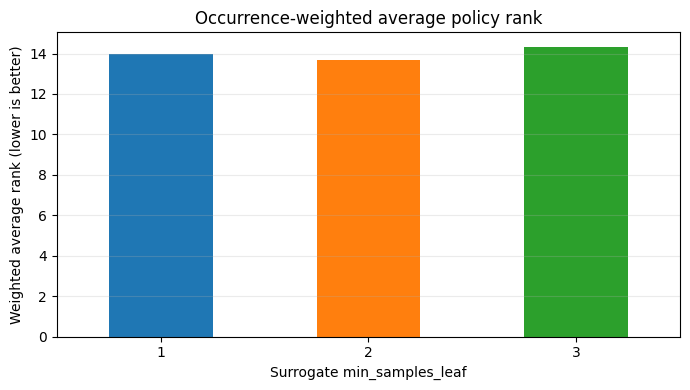

In [9]:
# Occurrence-weighted rank requested:
# sum(number of appearances in a policy * final policy rank) / 27.
weighted_rows = []
for leaf in (1, 2, 3):
    weighted_rank_sum = 0.0
    total_appearances = 0
    for result in adaptive_results:
        appearances = result["min_samples_leaf_by_block"].count(leaf)
        total_appearances += appearances
        weighted_rank_sum += appearances * policy_rank[result["policy_name"]]
    weighted_rows.append({
        "min_samples_leaf": leaf,
        "total_appearances": total_appearances,
        "weighted_rank_sum": weighted_rank_sum,
        "occurrence_weighted_average_rank": weighted_rank_sum / 27,
    })

leaf_rank_summary = pd.DataFrame(weighted_rows).set_index("min_samples_leaf")
display(leaf_rank_summary)

ax = leaf_rank_summary["occurrence_weighted_average_rank"].plot.bar(
    figsize=(7, 4), color=["tab:blue", "tab:orange", "tab:green"]
)
ax.set(
    title="Occurrence-weighted average policy rank",
    xlabel="Surrogate min_samples_leaf",
    ylabel="Weighted average rank (lower is better)",
)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

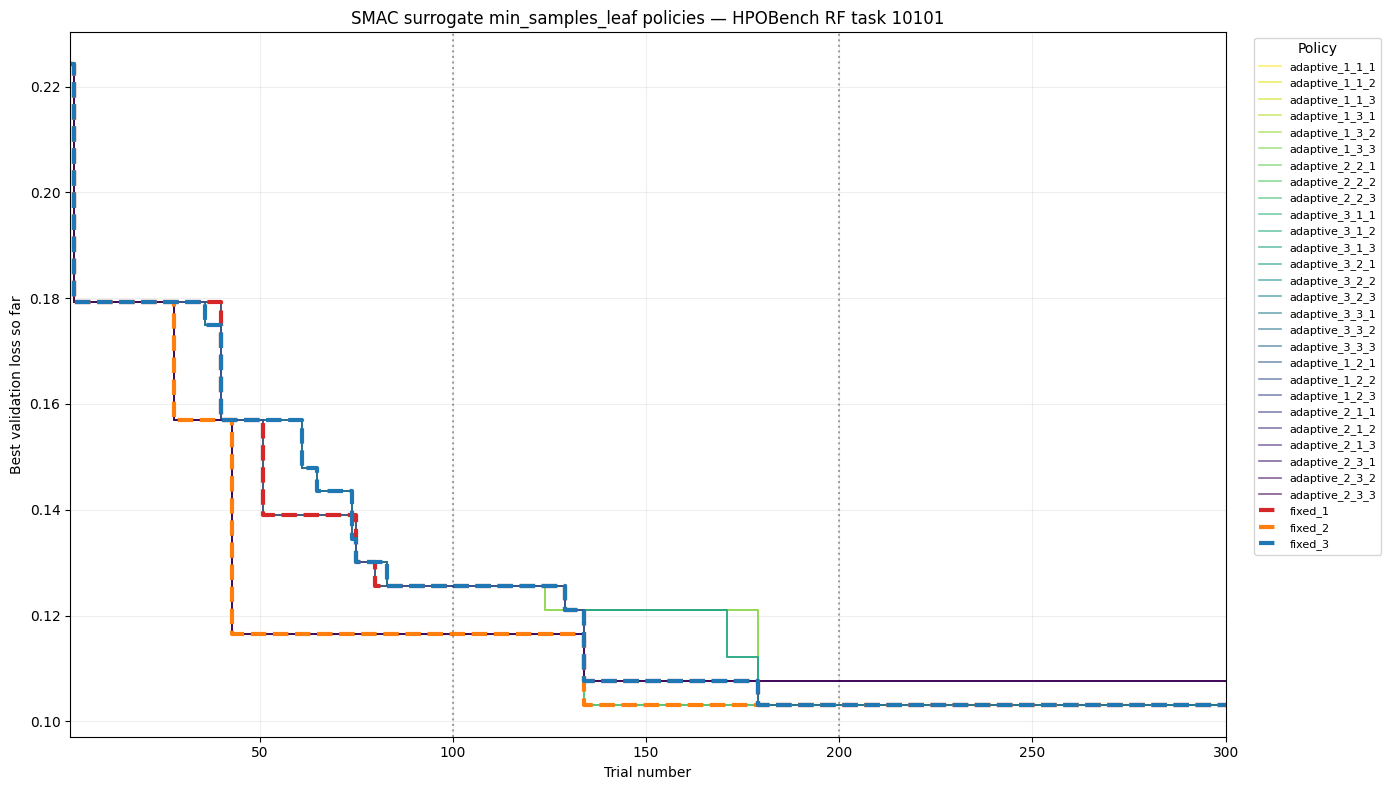

In [10]:
result_by_name = {result["policy_name"]: result for result in results}
adaptive_names = ranking.loc[ranking["type"] == "adaptive", "policy"].tolist()
fixed_names = ranking.loc[ranking["type"] == "fixed", "policy"].tolist()

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis_r([i / max(1, len(adaptive_names) - 1) for i in range(len(adaptive_names))])

for color, name in zip(colors, adaptive_names):
    result = result_by_name[name]
    ax.step(
        result["iteration"], result["best_so_far"], where="post",
        color=color, alpha=0.65, linewidth=1.2, label=name,
    )

fixed_colors = {"fixed_1": "tab:red", "fixed_2": "tab:orange", "fixed_3": "tab:blue"}
for name in fixed_names:
    result = result_by_name[name]
    ax.step(
        result["iteration"], result["best_so_far"], where="post",
        color=fixed_colors[name], linestyle="--", linewidth=3, label=name,
    )

for boundary in (100, 200):
    ax.axvline(boundary, color="black", linestyle=":", alpha=0.35)

ax.set(
    title="SMAC surrogate min_samples_leaf policies — HPOBench RF task 10101",
    xlabel="Trial number",
    ylabel="Best validation loss so far",
    xlim=(1, 300),
)
ax.grid(alpha=0.2)
ax.legend(title="Policy", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()